In [4]:
import numpy as np
from scipy.linalg import solve
from scipy.linalg import orthogonal_procrustes

# -------------------------------
# Simulation
# -------------------------------
# def simulate_ou_dfa(n_subjects=10, T_list=None, p=8000, k=5, rho=0.05, Q=1.0, Psi_scale=0.1, random_state=42):
#     np.random.seed(random_state)
#     if T_list is None:
#         T_list = [10]*n_subjects

#     Lambda_true = np.random.randn(p, k)
#     Ys = []
#     Zs = []
#     dts_all = []

#     for i, T in enumerate(T_list):
#         dt = np.random.uniform(0.5, 1.5, size=T-1)  # irregular dt
#         dts_all.append(dt)

#         z = np.zeros((T, k))
#         z[0] = np.random.randn(k)
#         for t in range(1, T):
#             A = np.exp(-rho * dt[t-1]) * np.eye(k)
#             z[t] = A @ z[t-1] + np.random.multivariate_normal(np.zeros(k), Q*np.eye(k))
#         noise = np.random.multivariate_normal(np.zeros(p), Psi_scale*np.eye(p), size=T)
#         y = z @ Lambda_true.T + noise
#         Ys.append(y)
#         Zs.append(z)

#     return Ys, Zs, Lambda_true, dts_all

import numpy as np

def simulate_ou_dfa(
    n_subjects=10,
    T_list=None,
    p=8000,
    k=5,
    rho_mean=0.05,
    rho_sd=0.03,
    Q_scale=0.3,
    Psi_scale=0.5,
    sparsity=0.7,
    shock_prob=0.05,
    shock_scale=3.0,
    random_state=42,
):
    """
    Harder OU-DFA simulation:
    - correlated latent OU dynamics
    - factor-specific decay
    - sparse & collinear loadings
    - heteroskedastic noise
    - latent shocks
    """
    rng = np.random.default_rng(random_state)

    if T_list is None:
        T_list = [10] * n_subjects

    # -----------------------
    # Loadings: sparse + collinear
    # -----------------------
    Lambda_true = rng.normal(0, 1, size=(p, k))

    mask = rng.uniform(size=(p, k)) > sparsity
    Lambda_true *= mask

    # induce collinearity
    if k > 1:
        Lambda_true[:, 1] += 0.8 * Lambda_true[:, 0]

    Lambda_true /= np.linalg.norm(Lambda_true, axis=0, keepdims=True)

    # -----------------------
    # Latent OU parameters
    # -----------------------
    rho = np.abs(rng.normal(rho_mean, rho_sd, size=k))

    # correlated innovation covariance
    R = rng.normal(size=(k, k))
    Q = Q_scale * (R @ R.T) / k

    Ys, Zs, dts_all = [], [], []

    for T in T_list:
        dt = rng.uniform(0.3, 2.0, size=T - 1)
        dts_all.append(dt)

        z = np.zeros((T, k))
        z[0] = rng.normal(0, 1, size=k)

        for t in range(1, T):
            A = np.diag(np.exp(-rho * dt[t - 1]))
            z[t] = A @ z[t - 1] + rng.multivariate_normal(np.zeros(k), Q)

            # latent shock (non-Gaussian)
            if rng.uniform() < shock_prob:
                z[t] += rng.normal(0, shock_scale, size=k)

        # heteroskedastic observation noise
        Psi_diag = Psi_scale * rng.lognormal(mean=0.0, sigma=0.5, size=p)
        noise = rng.normal(0, np.sqrt(Psi_diag), size=(T, p))

        y = z @ Lambda_true.T + noise

        Ys.append(y)
        Zs.append(z)

    return Ys, Zs, Lambda_true, dts_all

# -------------------------------
# Kalman Smoother (irregular dt)
# -------------------------------
def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]

    m = np.zeros(k)
    P = np.eye(k)
    Ez = np.zeros((T, k))
    Ezz = np.zeros((T, k, k))

    R = Psi
    eps = 1e-5  # numeric stabilizer

    # Forward pass (Kalman filter)
    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            P = A @ P @ A.T + Q * np.eye(k)
            m = A @ m
        S = Lambda @ P @ Lambda.T + R + eps*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P
        Ez[t] = m
        Ezz[t] = P + np.outer(m, m)

    return Ez, Ezz

# -------------------------------
# EM Updates
# -------------------------------
def update_Lambda(Ez_all, Ezz_all, Ys, tau=1.0, lam=1.0, eps=1e-5):
    """
    Update factor loadings Lambda (p x k) with horseshoe shrinkage.
    Handles variable-length sequences (irregular visits).
    Ez_all: list of [T_i x k] latent expectations per subject
    Ezz_all: list of [T_i x k x k] latent covariances per subject
    Ys: list of [T_i x p] observations per subject
    tau, lam: shrinkage parameters (scalar or length-k)
    """
    p = Ys[0].shape[1]  # number of observed variables
    k = Ez_all[0].shape[1]  # number of factors

    # If tau or lam are scalars, broadcast to length k
    tau = np.full(k, tau) if np.isscalar(tau) else np.asarray(tau).reshape(k,)
    lam = np.full(k, lam) if np.isscalar(lam) else np.asarray(lam).reshape(k,)

    Lambda = np.zeros((p, k))

    # Compute sums over subjects and time
    Ezz_sum = np.zeros((k, k))
    Ezy_sum = np.zeros((k, p))

    for Y, Ez, Ezz in zip(Ys, Ez_all, Ezz_all):
        T = Y.shape[0]
        for t in range(T):
            Ezz_sum += Ezz[t]
            Ezy_sum += np.outer(Ez[t], Y[t])

    # Horseshoe ridge
    ridge = np.diag(1.0 / (tau * lam**2 + eps))

    # Solve for each observed dimension
    for j in range(p):
        Lambda[j] = np.linalg.solve(Ezz_sum + ridge, Ezy_sum[:, j])

    return Lambda



def update_Psi(Ys, Ez_all, Lambda, eps=1e-5):
    p = Ys[0].shape[1]
    num = np.zeros(p)
    den = 0
    for Y, Ez in zip(Ys, Ez_all):
        T = Y.shape[0]
        for t in range(T):
            res = Y[t] - Lambda @ Ez[t]
            num += res**2
            den += 1
    Psi = np.diag(num/den + eps)
    return Psi

# -------------------------------
# EM Loop (irregular dt)
# -------------------------------
def run_em(Ys, dts_all, k=3, n_iter=30):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)
    rho = 0.05
    Q = 1.0
    tau = 1.0
    lam = 1.0

    for it in range(n_iter):
        # E-step
        Ezs = []
        Ezzs = []
        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)

        # M-step
        Lambda = update_Lambda(Ezs, Ezzs, Ys, tau, lam)
        Psi = update_Psi(Ys, Ezs, Lambda)

        print(f"Iter {it:02d} | mean|Λ|={np.mean(np.abs(Lambda)):.3f}")

    return Lambda

# -------------------------------
# Factor recovery metric
# -------------------------------
def factor_recovery(L_true, L_est):
    # Procrustes alignment
    R, _ = orthogonal_procrustes(L_est, L_true)
    L_aligned = L_est @ R
    corr = np.corrcoef(L_true.ravel(), L_aligned.ravel())[0,1]
    return corr


Iter 00 | mean|Λ|=0.417 | MSE=0.7990
Iter 01 | mean|Λ|=0.332 | MSE=0.4644
Iter 02 | mean|Λ|=0.297 | MSE=0.4081
Iter 03 | mean|Λ|=0.276 | MSE=0.3932
Iter 04 | mean|Λ|=0.261 | MSE=0.3892
Iter 05 | mean|Λ|=0.249 | MSE=0.3905
Iter 06 | mean|Λ|=0.241 | MSE=0.3924
Iter 07 | mean|Λ|=0.235 | MSE=0.3928
Iter 08 | mean|Λ|=0.231 | MSE=0.3931
Iter 09 | mean|Λ|=0.227 | MSE=0.3941
Iter 10 | mean|Λ|=0.224 | MSE=0.3965
Iter 11 | mean|Λ|=0.221 | MSE=0.3998
Iter 12 | mean|Λ|=0.217 | MSE=0.4017
Iter 13 | mean|Λ|=0.214 | MSE=0.4020
Iter 14 | mean|Λ|=0.211 | MSE=0.4019
Iter 15 | mean|Λ|=0.208 | MSE=0.4017
Iter 16 | mean|Λ|=0.206 | MSE=0.4015
Iter 17 | mean|Λ|=0.203 | MSE=0.4013
Iter 18 | mean|Λ|=0.201 | MSE=0.4011
Iter 19 | mean|Λ|=0.198 | MSE=0.4010
Iter 20 | mean|Λ|=0.196 | MSE=0.4012
Iter 21 | mean|Λ|=0.193 | MSE=0.4020
Iter 22 | mean|Λ|=0.190 | MSE=0.4033
Iter 23 | mean|Λ|=0.188 | MSE=0.4044
Iter 24 | mean|Λ|=0.186 | MSE=0.4048
Iter 25 | mean|Λ|=0.184 | MSE=0.4048
Iter 26 | mean|Λ|=0.182 | MSE=0.4048
I

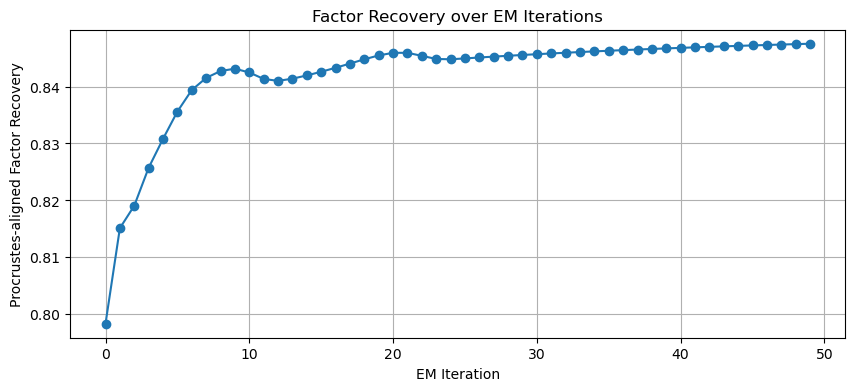

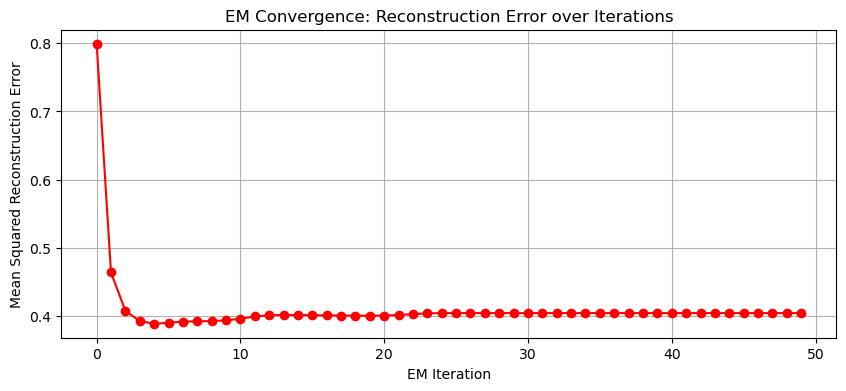

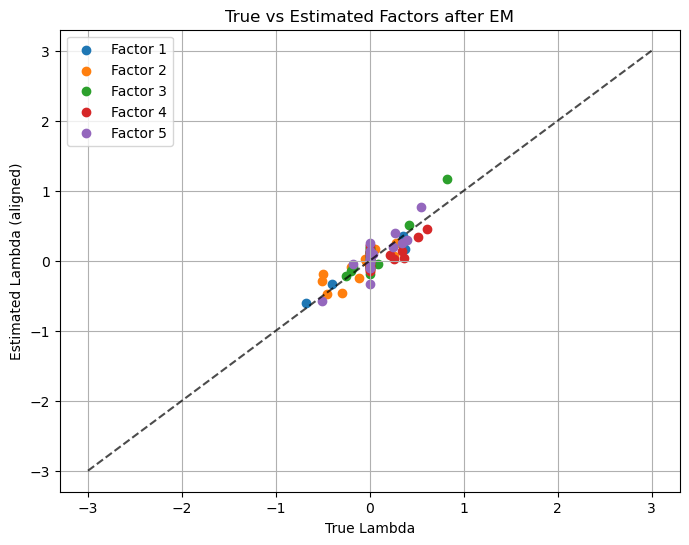

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import orthogonal_procrustes

# -------------------------------
# EM with history and reconstruction error
# -------------------------------
def run_em_with_history(Ys, dts_all, k=5, n_iter=30):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)
    rho = 0.05
    Q = 1.0
    tau = 1.0
    lam = 1.0

    history_Lambda = []
    mean_abs_history = []
    recon_error_history = []

    for it in range(n_iter):
        # E-step
        Ezs = []
        Ezzs = []
        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)

        # M-step
        Lambda = update_Lambda(Ezs, Ezzs, Ys, tau, lam)
        Psi = update_Psi(Ys, Ezs, Lambda)

        # Save history
        history_Lambda.append(Lambda.copy())
        mean_abs_history.append(np.mean(np.abs(Lambda)))

        # Compute mean squared reconstruction error
        mse = 0
        count = 0
        for Y, Ez in zip(Ys, Ezs):
            Y_hat = Ez @ Lambda.T
            mse += np.sum((Y - Y_hat)**2)
            count += Y.size
        recon_error_history.append(mse / count)

        print(f"Iter {it:02d} | mean|Λ|={np.mean(np.abs(Lambda)):.3f} | MSE={recon_error_history[-1]:.4f}")

    return Lambda, history_Lambda, mean_abs_history, recon_error_history

# -------------------------------
# Visualization
# -------------------------------
def plot_em_performance(Lambda_true, history_Lambda, recon_error_history):
    n_iter = len(history_Lambda)
    k = Lambda_true.shape[1]

    # Factor recovery over iterations
    recovery = []
    for L_est in history_Lambda:
        R, _ = orthogonal_procrustes(L_est, Lambda_true)
        L_aligned = L_est @ R
        corr = np.corrcoef(Lambda_true.ravel(), L_aligned.ravel())[0,1]
        recovery.append(corr)

    # Plot factor recovery
    plt.figure(figsize=(10,4))
    plt.plot(range(n_iter), recovery, marker='o')
    plt.xlabel("EM Iteration")
    plt.ylabel("Procrustes-aligned Factor Recovery")
    plt.title("Factor Recovery over EM Iterations")
    plt.grid(True)
    plt.show()

    # Plot reconstruction error
    plt.figure(figsize=(10,4))
    plt.plot(range(n_iter), recon_error_history, marker='o', color='r')
    plt.xlabel("EM Iteration")
    plt.ylabel("Mean Squared Reconstruction Error")
    plt.title("EM Convergence: Reconstruction Error over Iterations")
    plt.grid(True)
    plt.show()

    # True vs Estimated factors (final)
    L_final = history_Lambda[-1]
    R, _ = orthogonal_procrustes(L_final, Lambda_true)
    L_aligned = L_final @ R

    plt.figure(figsize=(8,6))
    for i in range(k):
        plt.scatter(Lambda_true[:, i], L_aligned[:, i], label=f"Factor {i+1}")
    plt.plot([-3,3], [-3,3], 'k--', alpha=0.7)
    plt.xlabel("True Lambda")
    plt.ylabel("Estimated Lambda (aligned)")
    plt.title("True vs Estimated Factors after EM")
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------------
# Main
# -------------------------------
def main_vis():
    n_subjects = 10
    T_list = [5,4,6,5,7,4,5,6,5,5]  # irregular T per subject
    Ys, Zs, Lambda_true, dts_all = simulate_ou_dfa(
        n_subjects=n_subjects,
        T_list=T_list,
        p=20,
        k=5
    )

    Lambda_est, history_Lambda, mean_abs_history, recon_error_history = run_em_with_history(Ys, dts_all, k=5, n_iter=50)
    rec = factor_recovery(Lambda_true, Lambda_est)
    print("\nProcrustes-aligned factor recovery:", rec)

    plot_em_performance(Lambda_true, history_Lambda, recon_error_history)

if __name__=="__main__":
    main_vis()
